# Counter Strike Case Values Linear Regression Pricing Model



In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import sklearn as sk



In [ ]:
# Step 1 Pick your data. Grab historical price data for one asset

data = pd.read_csv("Weapons_Case_Price_Data_CSGO.csv")
df = pd.DataFrame(data)
df.rename(columns={'Price (USD)': 'Price'}, inplace=True)
print(df.head())


                 Date  Price  Volume
0  Aug 14 2013 01: +0  8.528      38
1  Aug 15 2013 01: +0  5.436    5412
2  Aug 16 2013 01: +0  3.351    9877
3  Aug 17 2013 01: +0  2.621   11050
4  Aug 18 2013 01: +0  2.665   11485


In [ ]:
# Inputs for the linear regression model
name = input("Enter the name of the asset: ")
moving_average_window = int(input("Enter the moving average window size (Calculation): "))
volatility_window = int(input("Enter the volatility window size (Calculation): "))



In [ ]:
#Step 2 — Engineer your features. Transform price into things like daily returns 


df['Daily_Return'] = df['Price'].pct_change().shift(1)
df['Daily_Return'].fillna(0, inplace=True)  # Handle the NaN

## Add more features if needed, like moving averages, volatility, etc.

moving_average_window = int(input("Enter the moving average window size (Calculation): "))
volatility_window = int(input("Enter the volatility window size (Calculation): "))


df['Moving_Average'] = df['Price'].rolling(window=moving_average_window).mean().shift(1)  # Shift to avoid look-ahead bias
df['Volatility'] = df['Price'].rolling(window=volatility_window).std().shift(1)
df.dropna(inplace=True)  # Drop rows with NaN values from rolling calculations

# Step 3 — Train your model. Use linear regression to find the best fit line for your data
X = df[['Daily_Return', 'Moving_Average', 'Volatility']]
y = df['Price']
model = LinearRegression()
model.fit(X, y)




C:\Users\romeo\AppData\Local\Temp\ipykernel_13992\3739768711.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Daily_Return'].fillna(0, inplace=True)  # Handle the NaN


LinearRegression()

In [33]:
# Step 4 — Evaluate your model. Check how well it fits the data using metrics like R-squared
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R-squared: {r2}")




# Step 5 — Make predictions. Use your model to predict future prices based on new data
return_window = int(input("Enter the return window size (Example): "))
moving_average_window = int(input("Enter the moving average window size (Example): "))
volatility_window = int(input("Enter the volatility window size (Example): "))



# Predicting the price for the next day using the last known features!!!!
new_data = pd.DataFrame({
    'Daily_Return': [return_window],  # Example daily return
    'Moving_Average': [moving_average_window],   # Example moving average
    'Volatility': [volatility_window]         # Example volatility
}) 

predicted_price = model.predict(new_data)
print(f"Predicted Price: {predicted_price[0]}")


R-squared: 0.9785509668897469
Predicted Price: 212.25128126687974


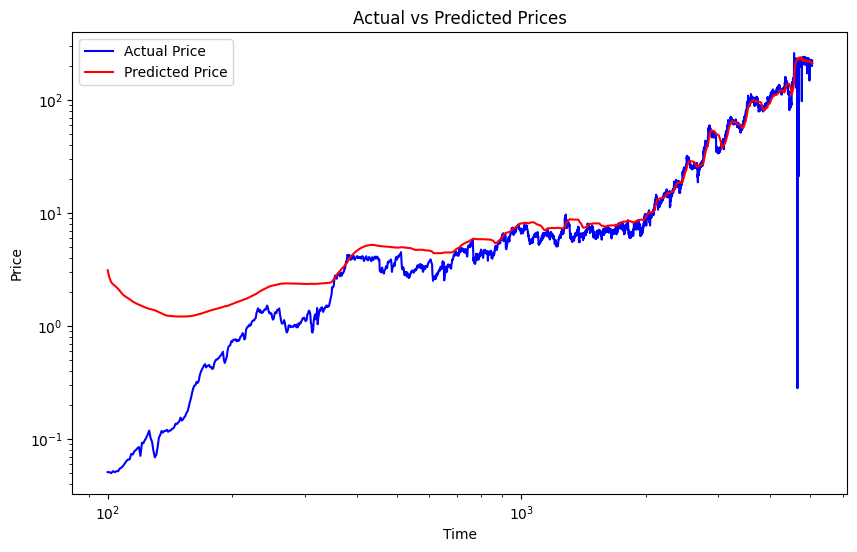

In [ ]:
# Plotting the actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.loglog(df.index, y, color='blue', label='Actual Price')
plt.loglog(df.index, y_pred, color='red', label='Predicted Price')
plt.title(f'Actual vs Predicted {name}'s Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()